In [ ]:
!pip show matplotlib seaborn scikit-learn tensorflow


Name: matplotlib
Version: 3.10.0
Summary: Python plotting package
Home-page: https://matplotlib.org
Author: John D. Hunter, Michael Droettboom
Author-email: Unknown <matplotlib-users@python.org>
License: License agreement for matplotlib versions 1.3.0 and later

 1. This LICENSE AGREEMENT is between the Matplotlib Development Team
 ("MDT"), and the Individual or Organization ("Licensee") accessing and
 otherwise using matplotlib software in source or binary form and its
 associated documentation.

 2. Subject to the terms and conditions of this License Agreement, MDT
 hereby grants Licensee a nonexclusive, royalty-free, world-wide license
 to reproduce, analyze, test, perform and/or display publicly, prepare
 derivative works, distribute, and otherwise use matplotlib
 alone or in any derivative version, provided, however, that MDT's
 License Agreement and MDT's notice of copyright, i.e., "Copyright (c)
 2012- Matplotlib Development Team; All Rights Reserved" are retained in
 matplotlib

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from pathlib import Path
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs available: {len(gpus)}')

TensorFlow version: 2.20.0
GPUs available: 2


In [ ]:
results_dir = "results/RipeVsUnripe/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

In [ ]:
!nvidia-smi
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'\nGPUs available: {len(gpus)}')
    for gpu in gpus:
        print(f' - {gpu}')
else:
    print('\nNo GPU found — training will run on CPU (slower).')

Tue Jul 28 12:18:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
from pathlib import Path

# 1. Path Identification (Applying Step 5 principles)
# Updated to the exact train directory in your new Kaggle dataset
kaggle_input_path = "/kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/train"
base_path = Path(kaggle_input_path)

print(f"Checking Base Directory: {base_path}")
print("-" * 50)

# 2. Directory Exploration and Data Verification (Applying Step 8 principles)
if base_path.exists():
    for class_folder in os.listdir(base_path):
        folder_path = base_path / class_folder

        # Ensure we are only looking at directories (filtering out random hidden files)
        if folder_path.is_dir():
            # Data Cleaning Principle: explicitly count only valid image formats
            jpg_count = len(list(folder_path.glob('*.jpg')))
            png_count = len(list(folder_path.glob('*.png')))
            jpeg_count = len(list(folder_path.glob('*.jpeg')))
            total_images = jpg_count + png_count + jpeg_count

            print(f"Class Folder Detected : '{class_folder}'")
            print(f" -> Valid Images Found: {total_images}")

            # Tag the folders so you know exactly which ones matter for the binary model
            if class_folder in ['ripe', 'unripe']:
                print(" -> STATUS: TARGET CLASS (Will be used)")
            else:
                print(" -> STATUS: IGNORED (Will be filtered out)")

            print("-" * 50)
else:
    print("Path does not exist! Please check the Kaggle input directory.")

Checking Base Directory: /kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/train
--------------------------------------------------
Class Folder Detected : 'unripe'
 -> Valid Images Found: 1902
 -> STATUS: TARGET CLASS (Will be used)
--------------------------------------------------
Class Folder Detected : 'overripe'
 -> Valid Images Found: 2349
 -> STATUS: IGNORED (Will be filtered out)
--------------------------------------------------
Class Folder Detected : 'rotten'
 -> Valid Images Found: 4020
 -> STATUS: IGNORED (Will be filtered out)
--------------------------------------------------
Class Folder Detected : 'ripe'
 -> Valid Images Found: 3522
 -> STATUS: TARGET CLASS (Will be used)
--------------------------------------------------


In [ ]:
# Set the base directory to your verified Kaggle path
BASE_DIR = Path('/kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset')

# Define the explicit paths since this dataset is already pre-split
TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR = BASE_DIR / 'valid'
TEST_DIR = BASE_DIR / 'test'

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3
SEED = 42 # Added to ensure reproducibility

print(f'Base Directory: {BASE_DIR}')
print(f'Image size  : {IMAGE_HEIGHT} x {IMAGE_WIDTH}')
print(f'Batch size  : {BATCH_SIZE}')
print(f'Max epochs  : {EPOCHS}')
print(f'Learning rate: {LR}')
print("-" * 50)

Base Directory: /kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset
Image size  : 128 x 128
Batch size  : 64
Max epochs  : 50
Learning rate: 0.001
--------------------------------------------------


In [ ]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=['ripe', 'unripe'], # The magic filter
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

print("\nLoading Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=['ripe', 'unripe'],
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

print("\nLoading Test Data:")
test_dataset = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    class_names=['ripe', 'unripe'],
    seed=SEED,
    image_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
num_classes = len(class_names)
print(f'\nClasses ({num_classes}): {class_names}')
print(f"Dataset Successfully Loaded and Filtered for Binary Classification!")

Loading Training Data:
Found 5424 files belonging to 2 classes.


I0000 00:00:1785241141.448919      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785241141.451840      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Loading Validation Data:
Found 506 files belonging to 2 classes.

Loading Test Data:
Found 264 files belonging to 2 classes.

Classes (2): ['ripe', 'unripe']
Dataset Successfully Loaded and Filtered for Binary Classification!


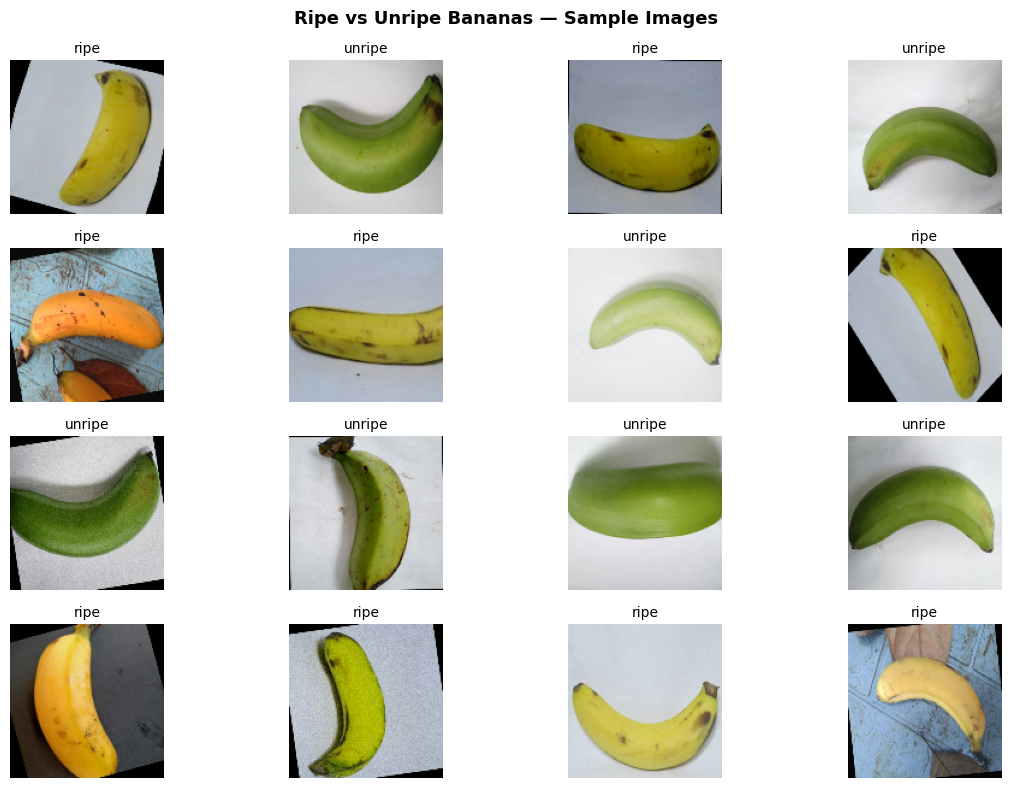

In [ ]:
# STEP 14: Sanity-Check (visualise dataset samples).
# Capture one fixed batch so the visualisation is stable across re-runs
for images, labels in train_dataset.take(1):
    fixed_images = images.numpy()
    fixed_labels = labels.numpy()

# STEP 15: Visualise the first 16 images and their labels
plt.figure(figsize=(12, 8))
for i in range(min(16, len(fixed_images))):
    ax = plt.subplot(4, 4, i + 1)
    plt.imshow(fixed_images[i].astype('uint8'))
    plt.title(class_names[fixed_labels[i]], fontsize=10)
    plt.axis('off')

plt.suptitle('Ripe vs Unripe Bananas — Sample Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{results_dir}banana_samples.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)
print('\nPipeline optimised with cache + shuffle + prefetch.')


Pipeline optimised with cache + shuffle + prefetch.


In [ ]:
data_augmentation = tf.keras.Sequential([
    # Updated: Bananas can be photographed from any angle, including upside down!
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
], name='data_augmentation')

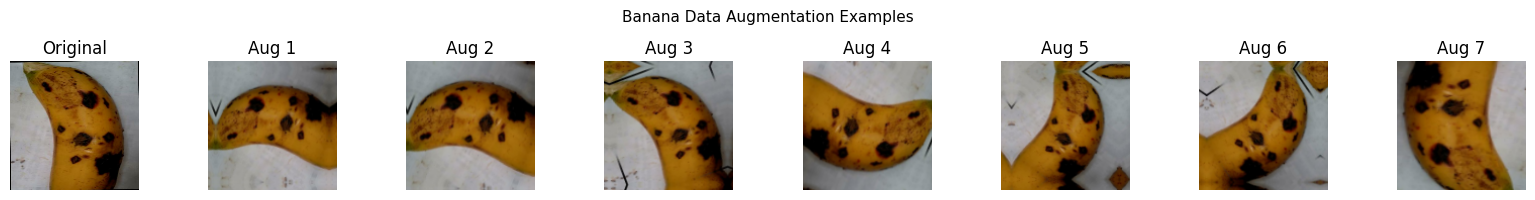

In [ ]:
for images, _ in train_dataset.take(1):
    sample = images[0:1]
    break

fig, axes = plt.subplots(1, 8, figsize=(16, 2))
axes[0].imshow(sample[0].numpy().astype('uint8'))
axes[0].set_title('Original')
axes[0].axis('off')

for i in range(1, 8):
    aug_img = data_augmentation(sample, training=True)[0].numpy().astype('uint8')
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Aug {i}')
    axes[i].axis('off')

# Updated title to fit the fruit theme
plt.suptitle('Banana Data Augmentation Examples', fontsize=11)
plt.tight_layout()

# Updated the filename so it doesn't say lab8
plt.savefig(f'{results_dir}banana_augmentation.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf

# Ensure the models directory exists in Kaggle's working path
models_dir = "/kaggle/working/models/"
os.makedirs(models_dir, exist_ok=True)

def make_callbacks(name):
    """Return a fresh set of callbacks for each model."""
    return [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=f'{models_dir}{name}_best.keras',
            monitor='val_accuracy',
            save_best_only=True,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=4,
            min_lr=1e-7,
            verbose=1
        ),
    ]

def plot_learning_curves(history, title='Learning Curves'):
    """Plot accuracy and loss curves side-by-side."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', linewidth=2)
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', linewidth=2)
    plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2, linestyle='--')
    plt.legend()
    plt.title(f'{title} — Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{results_dir}banana_{title.lower().replace(" ", "_")}_curves.png', dpi=120, bbox_inches='tight')
    plt.show()

def evaluate_model(model, dataset, class_names, title='Model'):
    """Evaluate a multiclass classification model."""
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        # multiclass prediction (softmax -> argmax)
        preds = np.argmax(probs, axis=1)
        y_prob.append(probs)
        y_pred.append(preds)
        y_true.append(labels.numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    y_prob = np.concatenate(y_prob)

    print(f"\n{title}")
    print(f'Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'Precision : {precision_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'Recall    : {recall_score(y_true, y_pred, average="weighted"):.4f}')
    print(f'F1-Score  : {f1_score(y_true, y_pred, average="weighted"):.4f}')
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm, cmap='Blues', cbar=False, annot=True, fmt='d',
        xticklabels=class_names, yticklabels=class_names,
        annot_kws={'fontsize': 12, 'fontweight': 'bold'}
    )
    plt.title(f'{title} — Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    # FIXED: changed lab8 to banana
    plt.savefig(f'{results_dir}banana_{title.lower().replace(" ", "_")}_confusion.png', dpi=120, bbox_inches='tight')
    plt.show()

    return accuracy_score(y_true, y_pred)

print('Callbacks and utility functions defined.')

Callbacks and utility functions defined.


In [ ]:
import tensorflow as tf

def build_custom_cnn(input_shape, augmentation):
    inputs = tf.keras.Input(shape=input_shape)

    x = augmentation(inputs)
    x = tf.keras.layers.Rescaling(1.0 / 255)(x)

    BN_MOMENTUM = 0.85

    # Block 1: 32 filters
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 2: 64 filters
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Block 3: 128 filters
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization(momentum=BN_MOMENTUM)(x)
    x = tf.keras.layers.MaxPooling2D()(x)

    # Classification Head
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.5)(x) # Safe here at the end of the pipeline

    # Binary output
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name='custom_cnn_completely_fixed')

INPUT_SHAPE = (IMAGE_HEIGHT, IMAGE_WIDTH, 3)
cnn_model = build_custom_cnn(INPUT_SHAPE, data_augmentation)

# Display the architecture
cnn_model.summary()

print("\nCompiling Fixed Custom CNN...")
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("\nStarting Training for Fixed Custom CNN...")
cnn_history = cnn_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('custom_cnn_completely_fixed'),
    verbose=1
)

Model: "custom_cnn_completely_fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 322,338 (1.23 MB)

 Trainable params: 321,442 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Compiling Fixed Custom CNN...

Starting Training for Fixed Custom CNN...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 26s 200ms/step - accuracy: 0.9817 - loss: 0.0464 - val_accuracy: 1.0000 - val_loss: 0.0031 - learning_rate: 0.0010
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - accuracy: 0.9954 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 5.7066e-04 - learning_rate: 0.0010
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9466 - val_loss: 0.1344 - learning_rate: 0.0010
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - accuracy: 0.9959 - loss: 0.0106 - val_accuracy: 0.9526 - val_loss: 0.2296 - learning_rate: 0.0010
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 164ms/step - accuracy: 0.9954 - loss: 0.0152 - val_accuracy: 1.0000 - val_loss: 2.1281e-04 - learning_rate: 0.0010
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 14s 166ms/step - accuracy: 0.9974 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 0.0016 - learning_rate: 0.0010


Custom CNN -> val_loss: 0.0000
val_accuracy: 1.0000

Generating Learning Curves...


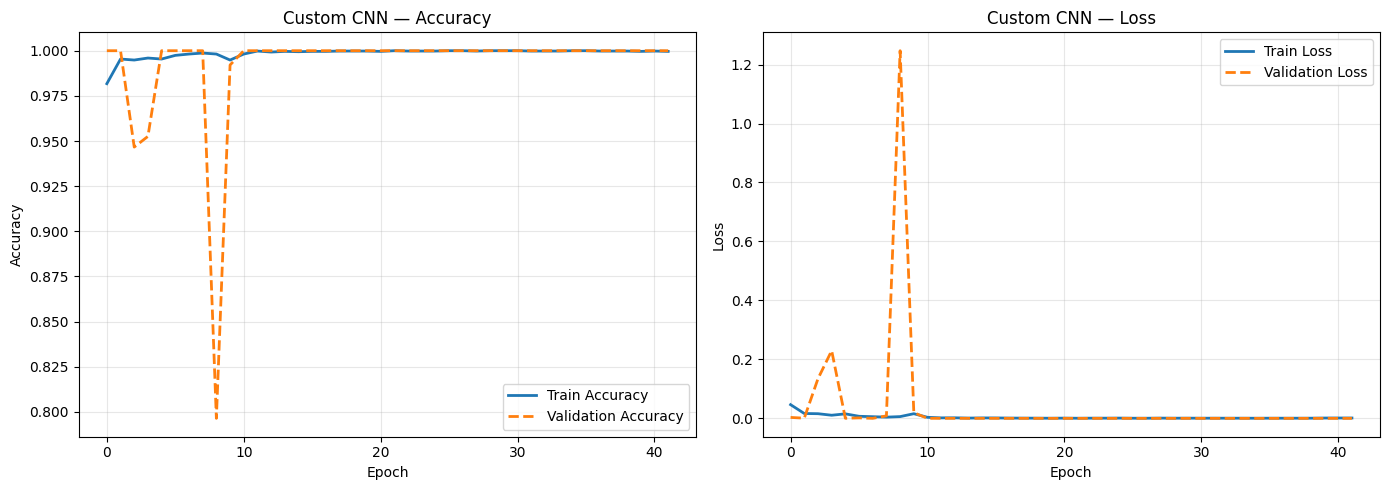


Evaluating Custom CNN on Test Dataset...

Custom CNN
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

        ripe     1.0000    1.0000    1.0000       154
      unripe     1.0000    1.0000    1.0000       110

    accuracy                         1.0000       264
   macro avg     1.0000    1.0000    1.0000       264
weighted avg     1.0000    1.0000    1.0000       264



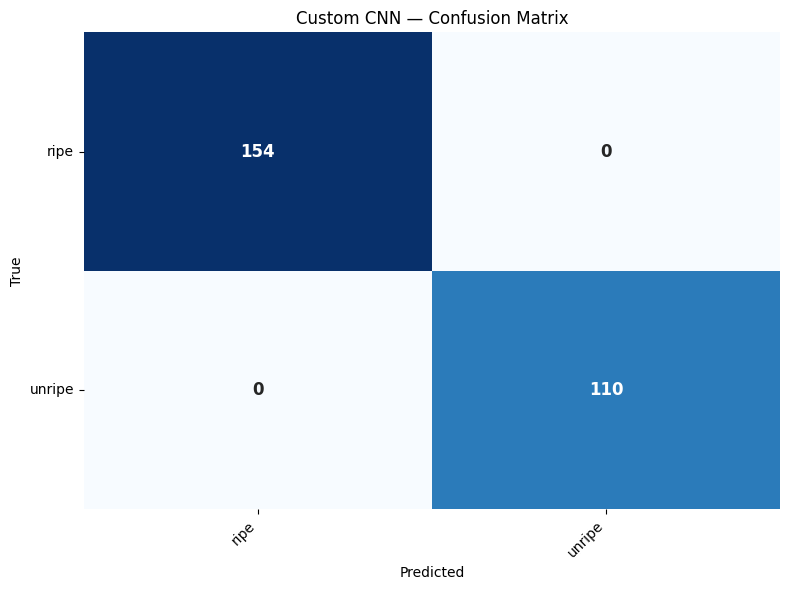

In [ ]:
cnn_val_loss, cnn_val_acc = cnn_model.evaluate(val_dataset, verbose=0)
print(f'Custom CNN -> val_loss: {cnn_val_loss:.4f}')
print(f'val_accuracy: {cnn_val_acc:.4f}')

print("\nGenerating Learning Curves...")
plot_learning_curves(cnn_history, 'Custom CNN')

print("\nEvaluating Custom CNN on Test Dataset...")
cnn_test_acc = evaluate_model(cnn_model, test_dataset, class_names, 'Custom CNN')

In [ ]:
# import tensorflow as tf

def build_transfer_model(input_shape, augmentation, backbone='mobilenetv3small'):
    """
    Feature extraction model:
    1. Augment input (training only)
    2. Preprocess for MobileNetV3 (scales to [-1, 1])
    3. Frozen MobileNetV3Small backbone (no top)
    4. GlobalAveragePooling2D
    5. Dense classification head
    """
    if backbone == 'mobilenetv3small':
        base_model = tf.keras.applications.MobileNetV3Small(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v3.preprocess_input
        model_name = 'mobilenetv3small_transfer'
    else:
        # Fallback: MobileNetV2
        base_model = tf.keras.applications.MobileNetV2(
            weights='imagenet',
            input_shape=input_shape,
            include_top=False,
        )
        preprocess_fn = tf.keras.applications.mobilenet_v2.preprocess_input
        model_name = 'mobilenetv2_transfer'

    # Freeze all base layers for feature extraction (no training)
    base_model.trainable = False
    print(f'Base model      : {base_model.name}')
    print(f'Trainable layers: {sum(1 for l in base_model.layers if l.trainable)} / {len(base_model.layers)}')

    # Build the model graph
    inputs = tf.keras.Input(shape=input_shape)
    x = augmentation(inputs)
    x = preprocess_fn(x) # scale pixels to [-1, 1]

    # frozen inference mode
    x = base_model(x, training=False)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    # Binary output: using num_classes to assign probabilities
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs, name=model_name), base_model

tl_model, base_model = build_transfer_model(INPUT_SHAPE, data_augmentation, backbone='mobilenetv3small')
tl_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model      : MobileNetV3Small
Trainable layers: 0 / 157


Model: "mobilenetv3small_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 4, 4, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,087,346 (4.15 MB)

 Trainable params: 148,226 (579.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
TL_LR = 1e-4

print("\nCompiling Transfer Learning Model...")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=TL_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

print("\nStarting Feature Extraction Training...")
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=make_callbacks('tl_feature_extraction'),
    verbose=1,
)


Compiling Transfer Learning Model...

Starting Feature Extraction Training...
Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.8955 - loss: 0.2557 - val_accuracy: 0.9881 - val_loss: 0.0610 - learning_rate: 1.0000e-04
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9840 - loss: 0.0677 - val_accuracy: 1.0000 - val_loss: 0.0232 - learning_rate: 1.0000e-04
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9923 - loss: 0.0357 - val_accuracy: 1.0000 - val_loss: 0.0115 - learning_rate: 1.0000e-04
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9956 - loss: 0.0246 - val_accuracy: 1.0000 - val_loss: 0.0068 - learning_rate: 1.0000e-04
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9958 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0044 - learning_rate: 1.0000e-04
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9978 - loss: 0.0131 - val_accuracy: 1.0000 - val_loss: 0.0033 - learning_rate: 1

MobileNetV3 TL -> val_loss: 0.0002
MobileNetV3 TL -> val_accuracy: 1.0000

Generating Learning Curves...


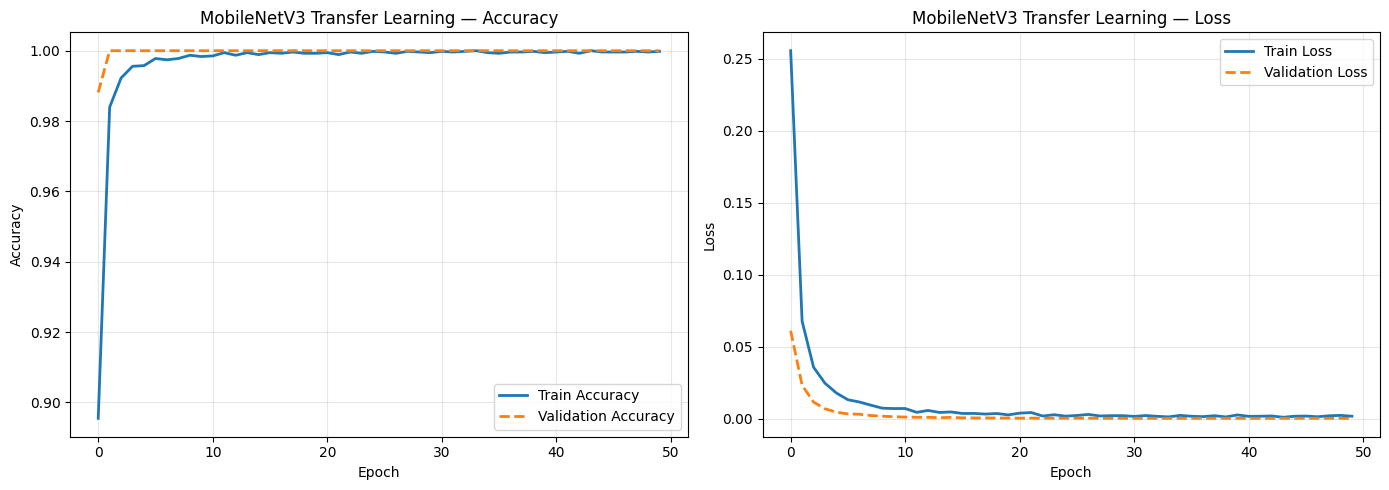


Evaluating MobileNetV3 TL on Test Dataset...

MobileNetV3 Transfer Learning
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

        ripe     1.0000    1.0000    1.0000       154
      unripe     1.0000    1.0000    1.0000       110

    accuracy                         1.0000       264
   macro avg     1.0000    1.0000    1.0000       264
weighted avg     1.0000    1.0000    1.0000       264



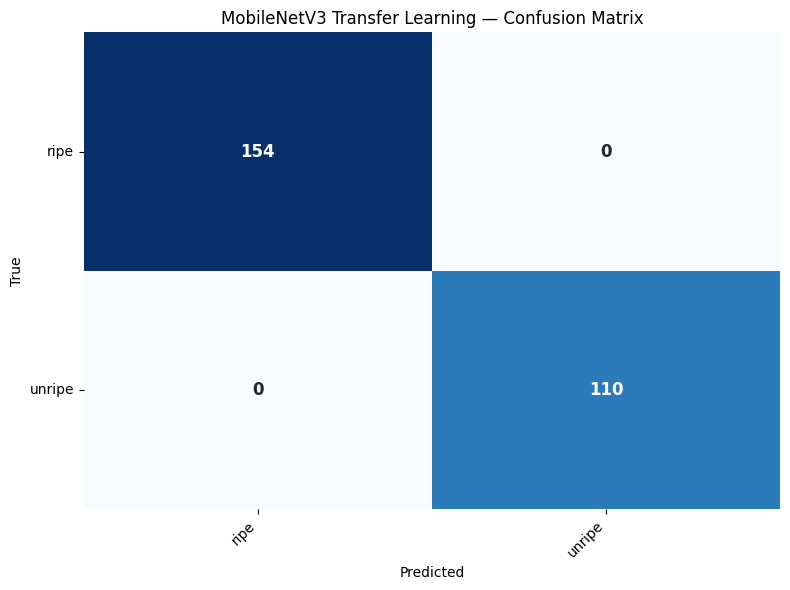

In [ ]:
tl_val_loss, tl_val_acc = tl_model.evaluate(val_dataset, verbose=0)
print(f'MobileNetV3 TL -> val_loss: {tl_val_loss:.4f}')
print(f'MobileNetV3 TL -> val_accuracy: {tl_val_acc:.4f}')

# Visualise the Learning curves
print("\nGenerating Learning Curves...")
plot_learning_curves(tl_history, 'MobileNetV3 Transfer Learning')

# Evaluate the model on the unseen test data
print("\nEvaluating MobileNetV3 TL on Test Dataset...")
tl_test_acc = evaluate_model(tl_model, test_dataset, class_names, 'MobileNetV3 Transfer Learning')

In [ ]:
print("Unfreezing the top 30 layers of the base model...")
base_model.trainable = True

# Freeze all layers EXCEPT the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Trainable base layers after unfreezing: {trainable_count} / {len(base_model.layers)}')

Unfreezing the top 30 layers of the base model...
Trainable base layers after unfreezing: 30 / 157


In [ ]:
FINETUNE_LR = TL_LR / 10

print(f"Recompiling with Fine-Tuning Learning Rate: {FINETUNE_LR}")
tl_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINETUNE_LR),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

Recompiling with Fine-Tuning Learning Rate: 1e-05


In [ ]:
print("\nStarting Fine-Tuning Training Phase...")
ft_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=make_callbacks('tl_finetuned'),
    verbose=2,
)


Starting Fine-Tuning Training Phase...
Epoch 1/20
85/85 - 13s - 150ms/step - accuracy: 0.9915 - loss: 0.0256 - val_accuracy: 1.0000 - val_loss: 1.6011e-04 - learning_rate: 1.0000e-05
Epoch 2/20
85/85 - 3s - 30ms/step - accuracy: 0.9948 - loss: 0.0158 - val_accuracy: 1.0000 - val_loss: 1.6493e-04 - learning_rate: 1.0000e-05
Epoch 3/20
85/85 - 2s - 29ms/step - accuracy: 0.9943 - loss: 0.0181 - val_accuracy: 1.0000 - val_loss: 1.6158e-04 - learning_rate: 1.0000e-05
Epoch 4/20
85/85 - 2s - 29ms/step - accuracy: 0.9959 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 1.9806e-04 - learning_rate: 1.0000e-05
Epoch 5/20

Epoch 5: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.
85/85 - 3s - 30ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 1.0000 - val_loss: 1.1864e-04 - learning_rate: 1.0000e-05
Epoch 6/20
85/85 - 3s - 30ms/step - accuracy: 0.9959 - loss: 0.0110 - val_accuracy: 1.0000 - val_loss: 1.1898e-04 - learning_rate: 3.0000e-06
Epoch 7/20
85/85 - 3s - 30ms

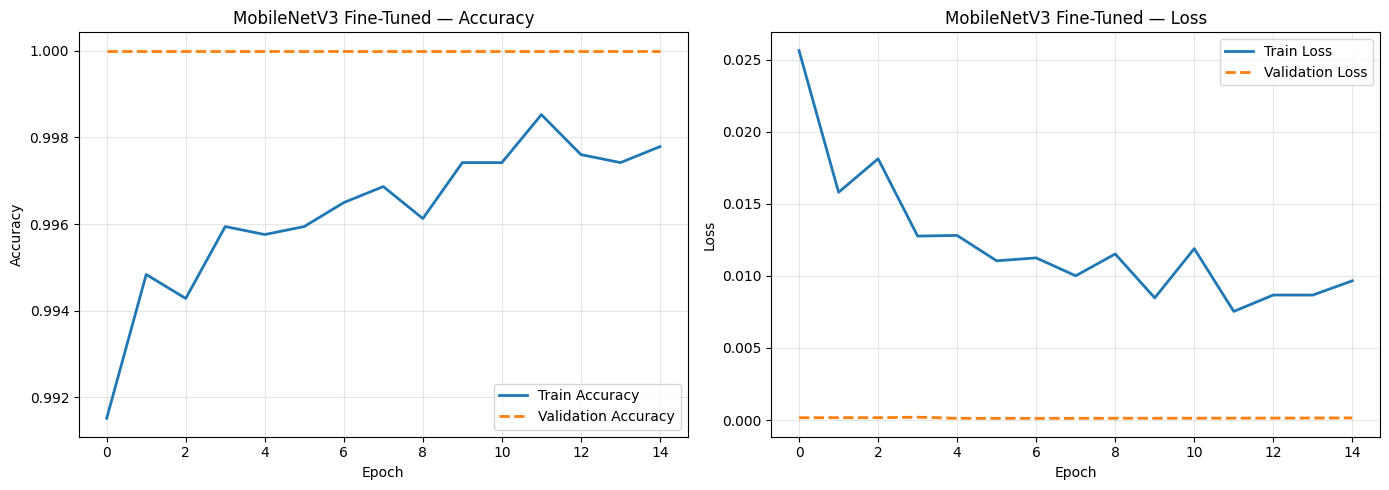

In [ ]:
plot_learning_curves(ft_history, 'MobileNetV3 Fine-Tuned')


Evaluating Fine-Tuned MobileNetV3 on Test Dataset...

MobileNetV3 Fine-Tuned
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

        ripe     1.0000    1.0000    1.0000       154
      unripe     1.0000    1.0000    1.0000       110

    accuracy                         1.0000       264
   macro avg     1.0000    1.0000    1.0000       264
weighted avg     1.0000    1.0000    1.0000       264



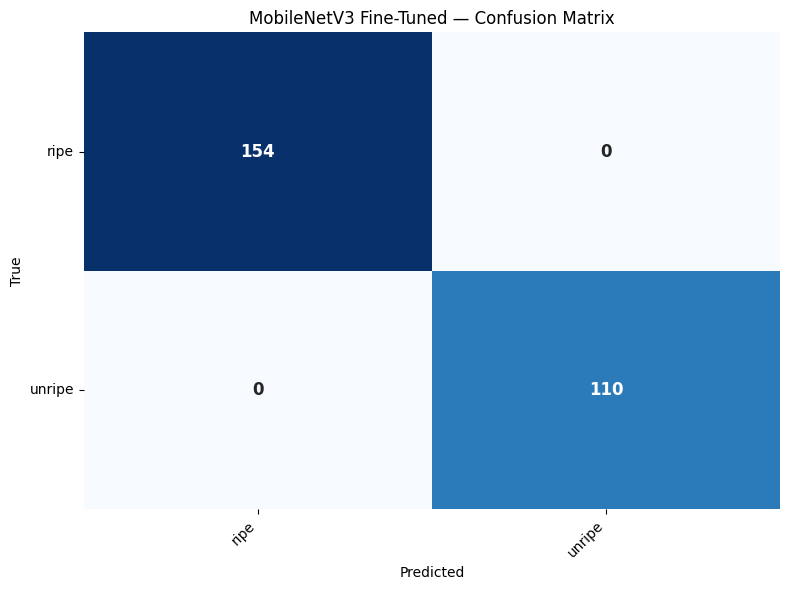

In [ ]:
print("\nEvaluating Fine-Tuned MobileNetV3 on Test Dataset...")
ft_test_acc = evaluate_model(
    tl_model,
    test_dataset,
    class_names,
    'MobileNetV3 Fine-Tuned'
)

In [ ]:
results = {
    'Custom CNN': {
        'acc': cnn_test_acc,
        'params': cnn_model.count_params()
    },
    'MobileNetV3 (TL)': {
        'acc': tl_test_acc,
        'params': tl_model.count_params()
    },
    'MobileNetV3 (FT)': {
        'acc': ft_test_acc,
        'params': tl_model.count_params()
    }
}

print(f'{"Model":<25} {"Test Acc":>10} {"Params":>14}')
print('-' * 55)
for name, vals in results.items():
    print(f'{name:<25} {vals["acc"]:>10.4f} {vals["params"]:>14,}')

Model                       Test Acc         Params
-------------------------------------------------------
Custom CNN                    1.0000        322,338
MobileNetV3 (TL)              1.0000      1,087,346
MobileNetV3 (FT)              1.0000      1,087,346


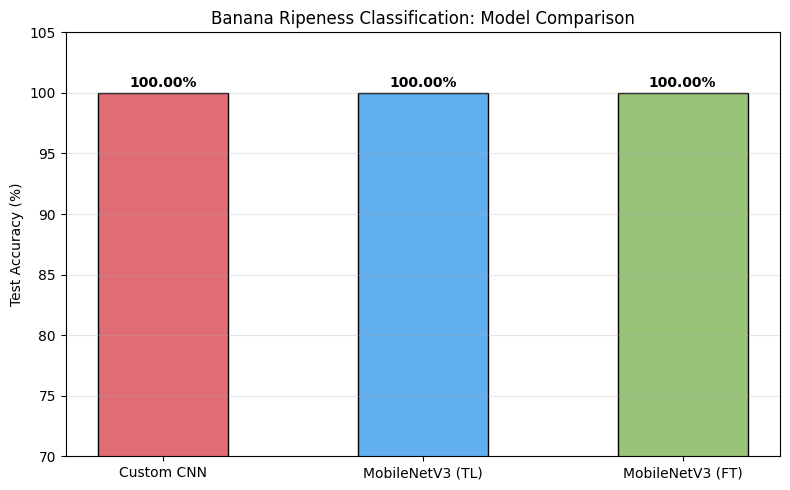

In [ ]:
labels = list(results.keys())
accs = [v['acc'] * 100 for v in results.values()]

# Added a third color (#98c379) to match our 3 models
colors = ['#e06c75', '#61afef', '#98c379']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, accs, color=colors, edgecolor='black', width=0.5)

ax.set_ylim(70, 105)
ax.set_ylabel('Test Accuracy (%)')
# FIXED: Banana title
ax.set_title('Banana Ripeness Classification: Model Comparison')
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accs):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{acc:.2f}%',
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
# FIXED: Banana filename
plt.savefig(f'{results_dir}banana_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

def predict_image(img_path, models_dict, class_names, image_size=(128, 128)):
    """Load an image file and classify it with each model in models_dict."""
    img = tf.keras.utils.load_img(img_path, target_size=image_size)
    img_array = tf.keras.utils.img_to_array(img)

    # Scale to [0, 255] float32 (assuming model handles scaling, or scale to [0, 1] if needed)
    img_array = np.expand_dims(img_array, axis=0) # (1, H, W, 3)

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

    print(f'\nPredictions for: {img_path}')
    print('-' * 40)
    for name, mdl in models_dict.items():
        # Handle predictions (assumes models output a single probability or a softmax array)
        preds = mdl.predict(img_array, verbose=0)[0]

        # If the output is a single node (binary), use preds[0]. If it's an array of 2 (softmax), use argmax.
        if len(preds) == 1:
            prob = preds[0]
            label = class_names[int(prob >= 0.5)]
        else:
            prob = np.max(preds)
            label = class_names[np.argmax(preds)]

        print(f'{name:<25}: {label} (confidence={prob:.4f})')




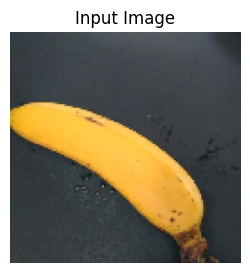


Predictions for: /kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/test/ripe/musa-acuminata-banana-ad772802-394a-11ec-996c-d8c4975e38aa_jpg.rf.ac1e17757ffe79f22868f68252821f9d.jpg
----------------------------------------
Custom CNN               : ripe (confidence=1.0000)
MobileNetV3 TL           : ripe (confidence=1.0000)
MobileNetV3 FT           : ripe (confidence=1.0000)


In [ ]:
test_image_path = '/kaggle/input/datasets/shahriar26s/banana-ripeness-classification-dataset/Banana Ripeness Classification Dataset/test/ripe/musa-acuminata-banana-ad772802-394a-11ec-996c-d8c4975e38aa_jpg.rf.ac1e17757ffe79f22868f68252821f9d.jpg'

models_to_test = {
    'Custom CNN': cnn_model,
    'MobileNetV3 TL': tl_model,
    'MobileNetV3 FT': tl_model  # You can also drop your fine-tuned model in here if you want!
}

try:
    predict_image(
        test_image_path,
        models_to_test,
        class_names
    )
except FileNotFoundError:
    print(f"Waiting for you to update the image path! Could not find: {test_image_path}")

In [ ]:

results_dir = "/kaggle/working/results/RipeVsUnripe/"
if not os.path.exists(results_dir):
    os.makedirs(results_dir, exist_ok=True)

# Save the models using the results_dir variable
cnn_model.save(f'{results_dir}custom_cnn.keras')
tl_model.save(f'{results_dir}mobilenetv3_transfer.keras')

print(f'Models saved successfully to the {results_dir} folder:')
print(f' -> {results_dir}custom_cnn.keras')
print(f' -> {results_dir}mobilenetv3_transfer.keras')

Models saved successfully to the /kaggle/working/results/RipeVsUnripe/ folder:
 -> /kaggle/working/results/RipeVsUnripe/custom_cnn.keras
 -> /kaggle/working/results/RipeVsUnripe/mobilenetv3_transfer.keras


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from PIL import Image

st.set_page_config(
    page_title="Banana Ripeness Classifier",
    page_icon="🍌",
    layout="centered",
)

st.markdown("""
<style>
    .main-title {
        font-size: 1.8rem;
        font-weight: 600;
        margin-bottom: 0.2rem;
    }
    .subtitle {
        color: #666;
        font-size: 0.95rem;
        margin-bottom: 1.5rem;
    }
</style>
""", unsafe_allow_html=True)

st.markdown('<div class="main-title">Banana Ripeness Classifier</div>', unsafe_allow_html=True)
st.markdown('<div class="subtitle">Upload a banana image to check if it is Ripe or Unripe.</div>', unsafe_allow_html=True)

# Load Model
@st.cache_resource
def load_model():
    return tf.keras.models.load_model("/kaggle/working/results/RipeVsUnripe/mobilenetv3_transfer.keras")

model = load_model()

# Prediction Function
def predict(model, pil_image):
    img = pil_image.convert("RGB").resize((128, 128))
    arr = np.expand_dims(np.array(img, dtype=np.float32), axis=0)
    preds = model.predict(arr, verbose=0)[0]

    # Class mapping based on alphabetical folder order (ripe, unripe)
    prob_ripe = float(preds[0])
    prob_unripe = float(preds[1])

    label = "Ripe" if prob_ripe >= prob_unripe else "Unripe"

    # Return both probabilities explicitly instead of just the max confidence
    return label, prob_ripe, prob_unripe

# File Uploader
uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file)

    # Display Image cleanly
    st.image(img, caption="Uploaded Image", width=300)

    if st.button("Classify Image", type="primary"):
        with st.spinner("Analyzing..."):
            label, prob_ripe, prob_unripe = predict(model, img)

        st.success(f"Result: **{label}**")

        # Display the breakdown using columns and progress bars
        st.write("### Confidence Breakdown")
        col1, col2 = st.columns(2)

        with col1:
            st.metric(label="Ripe", value=f"{prob_ripe * 100:.2f}%")
            st.progress(prob_ripe)

        with col2:
            st.metric(label="Unripe", value=f"{prob_unripe * 100:.2f}%")
            st.progress(prob_unripe)

Overwriting app.py


In [ ]:
!pip install -q streamlit
!npm install localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 77.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 91.4 MB/s eta 0:00:00:00:010:01
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 2s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸npm notice
npm notice New major version of npm available! 10.8.2 -> 12.0.1
npm notice Changelog: https://github.com/npm/cli/releases/tag/v12.0.1
npm notice To update run: npm install -g npm@12.0.1
npm notice
⠸

In [ ]:
!curl ipv4.icanhazip.com

35.239.37.107


In [ ]:
import os
import time
import subprocess

os.system("pkill -f streamlit")
os.system("pkill -f cloudflared")
time.sleep(5) # Wait 5 seconds for ports to clear

!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared

print("Starting Streamlit server...")
subprocess.Popen([
    "streamlit", "run", "app.py",
    "--server.port", "8501",
    "--server.address", "0.0.0.0",
    "--server.headless", "true"
])

time.sleep(6)

print("Opening Cloudflare tunnel...")
!./cloudflared tunnel --url http://localhost:8501

Starting Streamlit server...




2026-07-28 12:42:35.934 Uvicorn server started on 0.0.0.0:8501



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.19.2.2:8501
  External URL: http://35.239.37.107:8501

Opening Cloudflare tunnel...
2026-07-28T12:42:39Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-28T12:42:39Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-28T12:42:43Z INF +--------------------------------------------------------------------------------------------+

I0000 00:00:1785242591.381880    3039 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6526 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785242591.384072    3039 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13650 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  Stopping...
^C
2026-07-28T13:48:28Z INF Initiating graceful shutdown due to signal interrupt ...
2026-07-28T13:48:28Z ERR failed to run the datagram handler error="Application error 0x0 (remote)" connIndex=0 event=0 ip=198.41.192.37
2026-07-28T13:48:28Z ERR failed to serve tunnel connection error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.37
2026-07-28T13:48:28Z ERR Serve tunnel error error="accept stream listener encountered a failure while serving" connIndex=0 event=0 ip=198.41.192.37
2026-07-28T13:48:28Z INF Retrying connection in up to 1s connIndex=0 event=0 ip=198.41.192.37
2026-07-28T13:48:28Z ERR Connection terminated connIndex=0
2026-07-28T13:48:28Z ERR no more connections active and exiting
2026-07-28T13:48:28Z INF Tunnel server stopped
2026-07-28T13:48:28Z INF Metrics server stopped


In [ ]:
%%writefile requirements.txt
streamlit==1.36.0
tensorflow-cpu==2.15.0
numpy==1.26.4
pillow==10.3.0

Writing requirements.txt
